# AE 06: Opinion articles in The Arizona Daily Wildcat
### Author: Ripa Shah
### Date: 09/24/2025

## Part 1 - Data scraping

This will be done in the `wildcat-scrape.py` Python script within the `ae-06-wildcat-scrape` folder.
Save the resulting data frame in the `data/` folder.

## Part 2 - Data analysis

Let's start by loading the packages we will need:

In [154]:
%cd C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah


In [142]:
import pandas as pd
import os
import re

import requests

from bs4 import BeautifulSoup
import pandas as pd # Optional, for data storage
import time # Optional, for throttling requests

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from afinn import Afinn
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np
import ssl
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [211]:
from bs4 import BeautifulSoup
from urllib.request import urlopen

url = "https://wildcat.arizona.edu/category/opinions/"
page = urlopen(url)
page
html = page.read().decode("utf-8")
soup = BeautifulSoup(html, "html.parser")
text = soup.get_text()
#print(text)
#cleaned_text = text.strip()
#print(cleaned_text)

#cleaned_text2 = ' '.join(text.split())
#print(cleaned_text2)

#cleaned_text = re.sub(r'\s+', ' ', text).strip()
#print(cleaned_text)

#body_elements = soup.select('body')
#print(body_elements)




In [212]:

    #initialize list to scrape the information
titles = []
authors = []
dates = []
abstracts = []
columns = []
urls = []


for b in soup.select('.catlist-tile-inner'):
    title_tag = b.select('h2 a.homeheadline')
    for title in title_tag:
        title= title.get_text(strip=True) if title else 'NA'
    url_tag = b.select('h2 a.homeheadline href')
    for url in url_tag:
        url = title_tag['href'] if title_tag else 'N/A'
        print(title)
    author_tag = b.select('.catlist-writer')
    for author in author_tag:
        author= author.get_text(strip=True) if author else 'NA'
        print(author)
    date_tag = b.select('.catlist-date')
    for date in date_tag:
        date = date.get_text(strip=True) if date else 'NA'
        print(date)
    abstract_tag = b.select('.catlist-tile-textarea-with-media p')
    for abstract in abstract_tag:
        abstract = abstract.get_text(strip=True) if abstract else 'N/A'
        #print(f"'{abstract.get_text(strip=True)}'")
        print(abstract)
        
        # Assuming "column" is the category of the article, using title tag text for now
        column = 'Opinion'
        titles.append(title)
        authors.append(author)
        dates.append(date)
        abstracts.append(abstract)
        columns.append(column)
        urls.append(url)
    
        # Create a DataFrame
        #df = pd.DataFrame({
        #    'title': titles,
        #    'author': authors,
        #    'date': dates,
        #    'abstract': abstracts,
        #    'column': columns,
        #    'url': urls
        #})

        # Display the DataFrame
        #print(df)

        # Save to CSV if needed
        #df.to_csv('data\wildcat1.csv', index=False)

Mason Kumet
September 10, 2025
Eddie Barrón, Student Body Senator
August 27, 2025
Aiden Williams
July 21, 2025
Andres F. Diaz
July 2, 2025
Andres F. Diaz
June 3, 2025
Andres F. Diaz
May 24, 2025
Zaina Jasser
May 12, 2025
Kelley Benson
May 10, 2025
Valeria Nalani
May 10, 2025
Ian Stash
May 9, 2025
Ara Arellano
May 9, 2025
Isabel Vidrio
May 8, 2025
Zaina Jasser
May 6, 2025
Isabel Vidrio
May 6, 2025
Aiden Williams
May 6, 2025
Fiona Sievert
May 6, 2025
Ian Stash
April 30, 2025
Ian Stash
April 30, 2025
Quentin S. Agnello
April 22, 2025
Ara Arellano
April 16, 2025


#in below code I've generate a data file by implementing web scraping and saved in wildcat_author_opinion csv file. I've also created beautiful soup code generation.py file

In [ ]:
# Initialize the lists to store the data from all pages
all_data = []

#base url for pagination
# Initialize the lists to store the data from all pages
base_url = 'https://wildcat.arizona.edu/category/opinions/page/'

# Number of articles per page (Assuming it's 10, adjust as needed)
articles_per_page = 40

# Number of pages needed to get 500 articles
total_pages = 10

 
urls = [f"{base_url}{i}/" for i in range(1, total_pages + 1)]
print(urls)



['https://wildcat.arizona.edu/category/opinions/page/1/', 'https://wildcat.arizona.edu/category/opinions/page/2/', 'https://wildcat.arizona.edu/category/opinions/page/3/', 'https://wildcat.arizona.edu/category/opinions/page/4/', 'https://wildcat.arizona.edu/category/opinions/page/5/', 'https://wildcat.arizona.edu/category/opinions/page/6/', 'https://wildcat.arizona.edu/category/opinions/page/7/', 'https://wildcat.arizona.edu/category/opinions/page/8/', 'https://wildcat.arizona.edu/category/opinions/page/9/', 'https://wildcat.arizona.edu/category/opinions/page/10/']


In [ ]:
f#or url in urls:
  #  response = requests.get(url)
   # if response.status_code==200:        
        # Example: Extracting article titles
   #     for b in soup.select('.catlist-tile-inner'):
    #        title_tag = b.select('h2 a.homeheadline')
     #       for title in title_tag:
#                title= title.get_text(strip=True) if title else 'NA'
#                all_data.append({title})
#            url_tag = b.select('a.homeheadline href ')
#            for url1 in url_tag:
#                url1 = url1.get_text(strip=True) if url1 else 'NA'
#                all_data.append({url1})
#            author_tag = b.select('.catlist-writer')
#            for author in author_tag:
#                author= author.get_text(strip=True) if author else 'NA'
#                #rint(author)
#                all_data.append({author})
#            date_tag = b.select('.catlist-date')
#            for date in date_tag:
#                date = date.get_text(strip=True) if date else 'NA'
#                #rint(date)
#                all_data.append({date})
#            abstract_tag = b.select('.catlist-tile-textarea-with-media')
#            for abstract in abstract_tag:
#                abstract = abstract.get_text(strip=True) if abstract else 'N/A'
            
                #rint(f"'{abstract.get_text(strip=True)}'")
                #rint(abstract)
#                all_data.append({abstract})
                #all_data.append({f'Title| URL | Author | Date | Abstract '})
#            df = pd.DataFrame(all_data)
            # Optional: Add a delay to avoid overwhelming the server
#        time.sleep(1) 
#    else:
#        print(f"Failed to retrieve page: {all_data} (Status Code: {response.status_code})")




#df = pd.DataFrame({
 #   all_data
#})
#df.to_csv('data\wildcat_author_opinion.csv', index=True)
#print("Data saved to scraped_articles.csv")


Data saved to scraped_articles.csv


In [213]:
#print(soup.getText)

-   **Your turn (1 minute):** Load the data you saved into the `data` folder and name it `wildcat`.

In [192]:
# add code here
current_directory = os.getcwd()
print(current_directory)
file_path = os.path.join(current_directory, 'data', 'wildcat.csv')
df=pd.read_csv(file_path, encoding = 'iso-8859-1')
print(df)

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah
                                                 title            author  \
0    BOOK REVIEW: âFresh Fruit, Broken Bodiesâ ...    Andres F. Diaz   
1    OPINION: The first presidential debate lacked ...       Luke Lawson   
2    OPINION: College WBB favorites and sleeper pic...  Melisa Guzeloglu   
3    OPINION: College MBB favorites and sleeper pic...   Nathaniel Levin   
4    EDITORIAL: A desk altered but opinions thrive ...   Editor-in-Chief   
..                                                 ...               ...   
995                    Hereâs how to best help Nepal    Hailey Dickson   
996                        Adderall abuse not harmless    Maddie Pickens   
997                     Court rule is legitimate judge   Jacob Winkelman   
998                 Letters to the editor: May 4, 2015  Gabriel Schivone   
999            Capability imperfectly captured by TCEs    Maddie Pickens   

               da

-   **Your turn (3 minutes):** Who are the most prolific authors of the 100 most recent opinion articles in The Arizona Daily Wildcat?

In [193]:
# add code here
current_directory = os.getcwd()
print(current_directory)
file_path = os.path.join(current_directory, 'data', 'wildcat.csv')
df=pd.read_csv(file_path, encoding = 'iso-8859-1')


#print(df['author'])
cnt=0
author_counts = Counter(df['author'])
print(author_counts)
prolific_author = pd.DataFrame(author_counts.most_common(100), columns=['Author', 'count'])
print(prolific_author)

C:\Users\yashs\source\repos\Ripa-Shah\application-exercises-Ripa-Shah
Counter({'Greg Castro': 35, 'Toni Marcheva': 31, 'Apoorva Bhaskara': 28, 'Alec Scott': 26, 'Sean Fagan': 24, 'Daniel Geffre': 22, 'Chuck Valadez': 21, 'Scott Baca': 21, 'Julianna Strano': 20, 'Rhiannon Bauer': 20, 'Jacob Winkelman': 20, 'Hailey Dickson': 19, 'Talya Jaffe': 18, 'Kelly Marry': 17, 'Nick Havey': 17, 'Ashleigh Horowitz': 16, 'Maddie Pickens': 16, 'Payton Toomey': 15, 'Jessica Suriano': 15, 'Olivia Krupp': 14, 'Amanda Betz': 14, 'Aurora Begay': 14, 'Martin Forstrom': 14, 'Justice Amarillas': 14, 'Nicole Rochon': 13, 'Graham Place': 13, 'Sophie Applin': 12, 'Lauren Borelli': 12, 'Marissa Heffernan': 12, 'Claudia Drace': 12, 'Leah Gilchrist': 12, 'Jackson Morrison': 12, 'Michael Cortez': 12, 'Sophia Hammer': 11, 'Selena Kuikahi': 11, 'The Daily Wildcat Opinions Board': 11, 'Genesis Lara': 11, 'Cooper Temple': 11, 'Julian Cardenas': 10, 'Stephanie Shaw': 10, 'Sabrina Etcheverry': 10, 'Tanner Jean-Louis': 10,

In [ ]:
#print(df)

                                                 title            author  \
0    BOOK REVIEW: âFresh Fruit, Broken Bodiesâ ...    Andres F. Diaz   
1    OPINION: The first presidential debate lacked ...       Luke Lawson   
2    OPINION: College WBB favorites and sleeper pic...  Melisa Guzeloglu   
3    OPINION: College MBB favorites and sleeper pic...   Nathaniel Levin   
4    EDITORIAL: A desk altered but opinions thrive ...   Editor-in-Chief   
..                                                 ...               ...   
995                    Hereâs how to best help Nepal    Hailey Dickson   
996                        Adderall abuse not harmless    Maddie Pickens   
997                     Court rule is legitimate judge   Jacob Winkelman   
998                 Letters to the editor: May 4, 2015  Gabriel Schivone   
999            Capability imperfectly captured by TCEs    Maddie Pickens   

               date  abstract   column  \
0     July 22, 2024       NaN  Opinion   
1  

-   **Demo:** Draw a line plot of the number of opinion articles published per day in The Arizona Daily Wildcat.

          date  count
0   2015-10-25     19
1   2015-10-05     17
2   2015-10-19     14
3   2015-12-07     13
4   2015-11-30     11
..         ...    ...
578 2015-09-15      1
579 2015-08-29      1
580 2015-08-28      1
581 2015-08-25      1
582 2015-08-24      1

[583 rows x 2 columns]


C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2910138804.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='count', y='date',data=sort_cnt_articles, palette='PRGn')
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2910138804.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


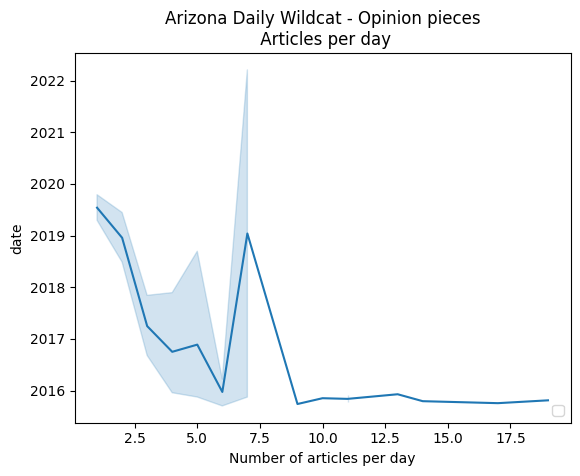

C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2910138804.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


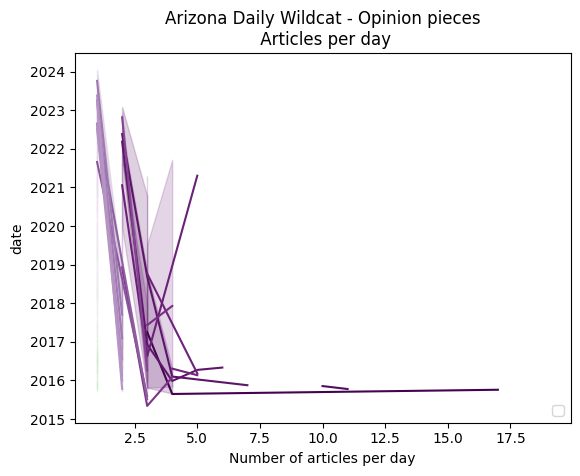

In [107]:
# add code here
df['date'] = pd.to_datetime(df['date'])
cnt_articles= Counter(df['date'])
#print(cnt_articles)
sort_cnt_articles= pd.DataFrame(cnt_articles.most_common(),columns=['date','count'])
print(sort_cnt_articles)
sort_cnt_articles['count']= pd.to_numeric(sort_cnt_articles['count'])

#prolific_author = pd.DataFrame(author_counts.most_common(100), columns=['Author', 'count'])
#print(prolific_author)
#sort_cnt_articles.sort()
#series = pd.Series(sort_cnt_articles)
#print(series)
#series.index = pd.to_datetime(series.index)

plt.Figure(figsize=(10,5))
sns.lineplot(x='count', y='date',data=sort_cnt_articles, palette='PRGn')
plt.legend(loc='lower right')
plt.xlabel('Number of articles per day')
plt.ylabel('date')
plt.title('Arizona Daily Wildcat - Opinion pieces\n Articles per day')
plt.show()

#series = series.sort_index()
plt.Figure(figsize=(10,5))
sns.lineplot(x='count', y='date',data=sort_cnt_articles, palette='PRGn',legend=None, hue=df['author'])
plt.legend(loc='lower right')
plt.xlabel('Number of articles per day')
plt.ylabel('date')
plt.title('Arizona Daily Wildcat - Opinion pieces\n Articles per day')
plt.show()






#sorted_by_value_asc = sorted(cnt_articles.items(), key=lambda item: item[1])
#print(sorted_by_value_asc)


#plt.figure(figsize=(10, 5))
#sns.lineplot(x='sorted', y='date',data='df', palette='viridis')
#plt.xlabel('Number of articles per day')
#plt.ylabel('date')
#plt.title('Arizona Daily Wildcat - Opinion pieces\n Articles per day')
#plt.show()


          date  count
0   2015-05-04      3
1   2015-05-05      3
2   2015-05-06      2
3   2015-05-13      2
4   2015-06-10      3
..         ...    ...
578 2024-02-28      1
579 2024-03-06      1
580 2024-03-15      3
581 2024-07-03      1
582 2024-07-22      1

[583 rows x 2 columns]


-   **Demo:** What percent of the most recent 100 opinion articles in The Arizona Daily Wildcat mention "climate" in their title?

  climate_mentioned  Percentage
0      not findable        0.99
1              find        0.01


C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2042732917.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['title_lower']=most_recent_title['title'].str.lower()
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2042732917.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['find_climate']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'climate' in x else 'not findable')
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2042732917.py:18: UserWarning: Ign

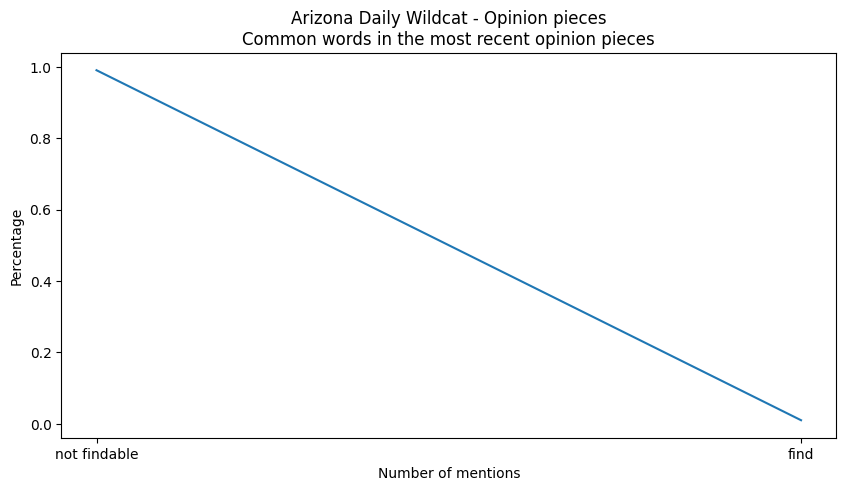

In [ ]:
# add code here

#stop_words = set(stopwords.words('english'))
#df['tokens'] = df['title'].apply(lambda x: [word.lower() for word in word_tokenize(x) if word.isalpha() and word.lower() not in stop_words])



most_recent_title = df.head(100)
most_recent_title['title_lower']=most_recent_title['title'].str.lower()
most_recent_title['find_climate']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'climate' in x else 'not findable')
climate_mentions= most_recent_title['find_climate'].value_counts(normalize=True).reset_index()
climate_mentions.columns = ['climate_mentioned','Percentage']
print(climate_mentions)
#word_counts = Counter(word for title in df['tokens'] for word in title)
#common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.lineplot(x='climate_mentioned', y='Percentage', data=climate_mentions, palette='viridis')
plt.xlabel('Number of Climate mentions')
plt.ylabel('Percentage')
plt.title('Arizona Daily Wildcat - Opinion pieces\nClimate in the most recent opinion pieces')
plt.show()

-   **Your turn (5 minutes):** What percent of the most recent 100 opinion articles in The Arizona Daily Wildcat mention "election" in their title or abstract?

  election_mentioned  Percentage
0       not findable         1.0


C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2596081078.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['title_lower']=most_recent_title['title'].str.lower()
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2596081078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['find_election']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'election' in x else 'not findable')
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\2596081078.py:13: UserWarning: Ig

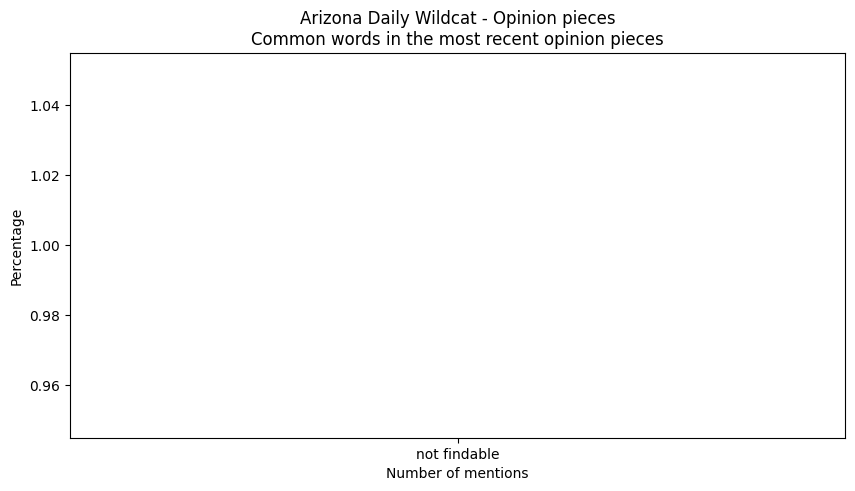

In [129]:
# add code here

most_recent_title = df.head(100)
most_recent_title['title_lower']=most_recent_title['title'].str.lower()
most_recent_title['find_election']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'election' in x else 'not findable')
election_mentions= most_recent_title['find_election'].value_counts(normalize=True).reset_index()
election_mentions.columns = ['election_mentioned','Percentage']
print(election_mentions)
#word_counts = Counter(word for title in df['tokens'] for word in title)
#common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.lineplot(x='election_mentioned', y='Percentage', data=election_mentions, palette='viridis')
plt.xlabel('Number of mentions')
plt.ylabel('Percentage')
plt.title('Arizona Daily Wildcat - Opinion pieces\nCommon words in the most recent opinion pieces')
plt.show()

-   **Time permitting:** Come up with another question and try to answer it using the data.

In [207]:
print(df)


                                                 title            author  \
0    BOOK REVIEW: âFresh Fruit, Broken Bodiesâ ...    Andres F. Diaz   
1    OPINION: The first presidential debate lacked ...       Luke Lawson   
2    OPINION: College WBB favorites and sleeper pic...  Melisa Guzeloglu   
3    OPINION: College MBB favorites and sleeper pic...   Nathaniel Levin   
4    EDITORIAL: A desk altered but opinions thrive ...   Editor-in-Chief   
..                                                 ...               ...   
995                    Hereâs how to best help Nepal    Hailey Dickson   
996                        Adderall abuse not harmless    Maddie Pickens   
997                     Court rule is legitimate judge   Jacob Winkelman   
998                 Letters to the editor: May 4, 2015  Gabriel Schivone   
999            Capability imperfectly captured by TCEs    Maddie Pickens   

               date  abstract   column  \
0     July 22, 2024       NaN  Opinion   
1  

  word_mentioned  Percentage
0   not findable         1.0


C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\493015992.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['title_lower']=most_recent_title['title'].str.lower()
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\493015992.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_recent_title['find_word']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'favourites' in x else 'not findable')
C:\Users\yashs\AppData\Local\Temp\ipykernel_43592\493015992.py:11: UserWarning: Ignorin

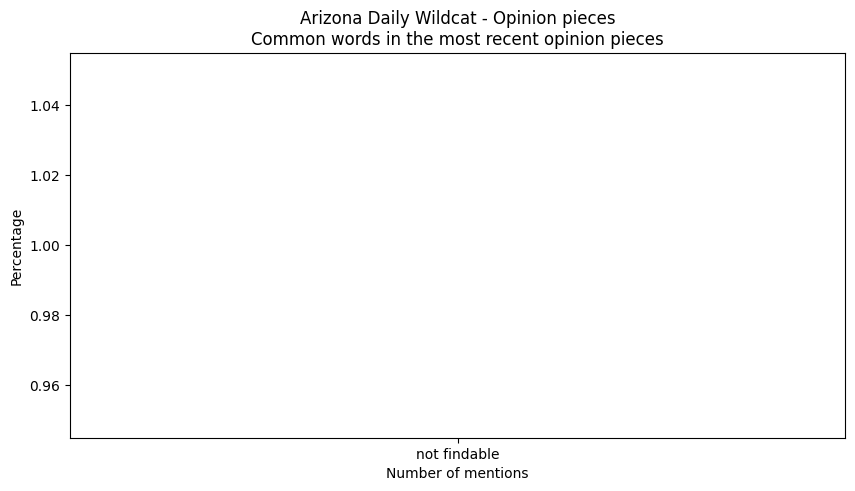

In [210]:
most_recent_title = df.head(1000)
most_recent_title['title_lower']=most_recent_title['title'].str.lower()
most_recent_title['find_word']=most_recent_title['title_lower'].apply(lambda x: 'find' if 'favourites' in x else 'not findable')
word_mentions= most_recent_title['find_word'].value_counts(normalize=True).reset_index()
word_mentions.columns = ['word_mentioned','Percentage']
print(word_mentions)
#word_counts = Counter(word for title in df['tokens'] for word in title)
#common_words = pd.DataFrame(word_counts.most_common(20), columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.lineplot(x='word_mentioned', y='Percentage', data=word_mentions, palette='viridis')
plt.xlabel('Number of mentions')
plt.ylabel('Percentage')
plt.title('Arizona Daily Wildcat - Opinion pieces\nCommon words in the most recent opinion pieces')
plt.show()

In [ ]:
#References:
#https://realpython.com/python-web-scraping-practical-introduction/
#https://github.com/INFO511-Fall2025/application-exercises-Ripa-Shah/blob/main/data/wildcat-scrape.py
#https://www.educative.io/answers/beautiful-soup-select
#https://sukhbinder.wordpress.com/2022/06/26/how-to-resolve-this-pandas-valueerror-arrays-must-all-be-same-length/
#https://www.practicalpythonfordatascience.com/ap_seaborn_palette
#https://stackoverflow.com/questions/60245366/having-problems-plotting-lineplot-in-seaborn-library
